In [1]:
!pip install matplotlib.pyplot
!pip install seaborn
!pip install plotly.express

ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


In [2]:
pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [3]:
import matplotlib.pyplot as plt

In [4]:
##SWIGGY SALES ANALYSIS

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [6]:
df = pd.read_excel("D:/swiggy_sales_analysis/swiggy_data.xlsx")

In [7]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [8]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [9]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


In [10]:
### META DATA

In [11]:
print("No of Rows :", df.shape[0])

No of Rows : 197430


In [12]:
print("No of Fields :", df.shape[1])

No of Fields : 10


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [14]:
### Data Types

In [15]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [16]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


In [17]:
###KPI'S

In [18]:
##Total Sales

In [19]:
total_sales= df["Price (INR)"].sum()
print("Total_Sales :" ,round(total_sales,2))

Total_Sales : 53012505.77


In [20]:
### AVERAGE RATING

In [21]:
Average_rating= df["Rating"].mean()
print("Avg_Rating :" , round(Average_rating,1))

Avg_Rating : 4.3


In [22]:
### Average Order Value

In [23]:
Average_order_value= df["Price (INR)"].mean()
print("Avg Order Value :" ,round(Average_order_value,2))

Avg Order Value : 268.51


In [24]:
### Ratings Count

In [25]:
Rating_Count= df["Rating Count"].sum()
print("Rating Count :" ,round(Rating_Count,2))

Rating Count : 5591574


In [26]:
###Total Orders

In [27]:
print("Total Orders :" ,len(df))

Total Orders : 197430


In [28]:
### Charts

In [29]:
### Monthly Sales Trends

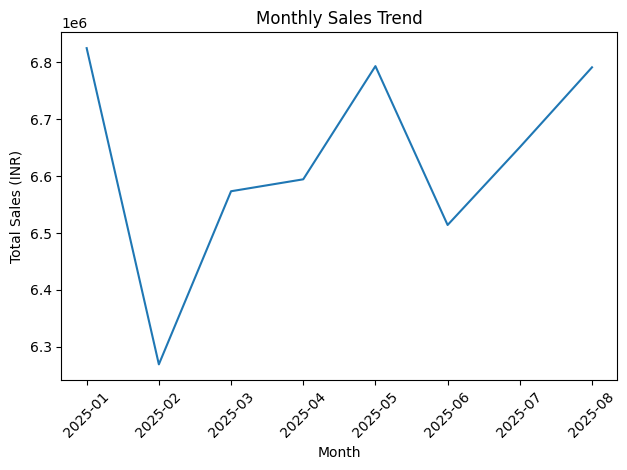

In [30]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_revenue = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()

plt.figure()
plt.plot(monthly_revenue["YearMonth"],monthly_revenue["Price (INR)"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Sales (INR)")
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.show()


In [31]:
###Daily Sales Trends

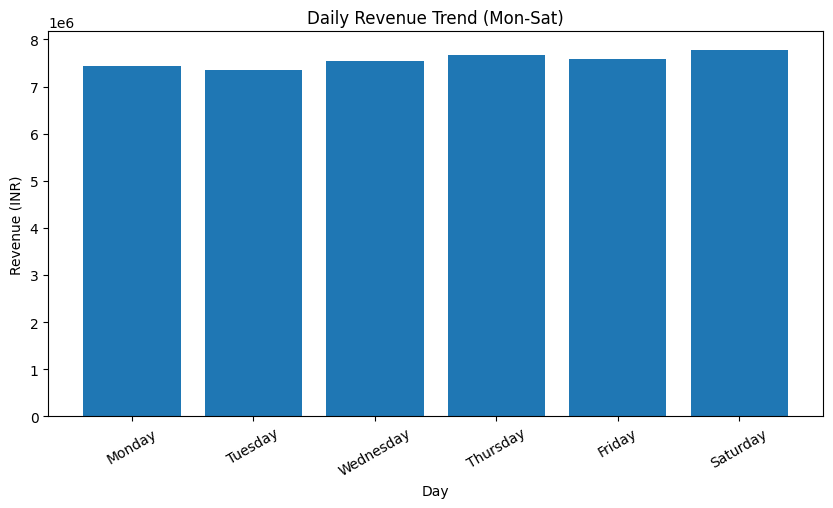

In [37]:
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()

daily_revenue = (
    df.groupby("DayName")["Price (INR)"].sum()
    .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"])

)

plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index,daily_revenue.values)
plt.title("Daily Revenue Trend (Mon-Sat)")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=30)

plt.show()

In [ ]:
### Total Sales By Food Type(Veg - Non Veg

In [41]:
non_veg_keywords = [
    "chicken", "egg", "fish", "mutton",
    "prawn", "briyani", "kabab", "kebab",
    "non-veg", "non veg"
]

df["Food Category"] = np.where(
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords), na=False),
    "Non-Veg",
    "Veg"
)

In [42]:
food_revenue = (
    df.groupby("Food Category")["Price (INR)"]
    .sum()
    .reset_index()
)

In [47]:
pip install plotly.express

Note: you may need to restart the kernel to use updated packages.


In [50]:
import plotly.express as px

In [ ]:
### Top 5 cities By sales

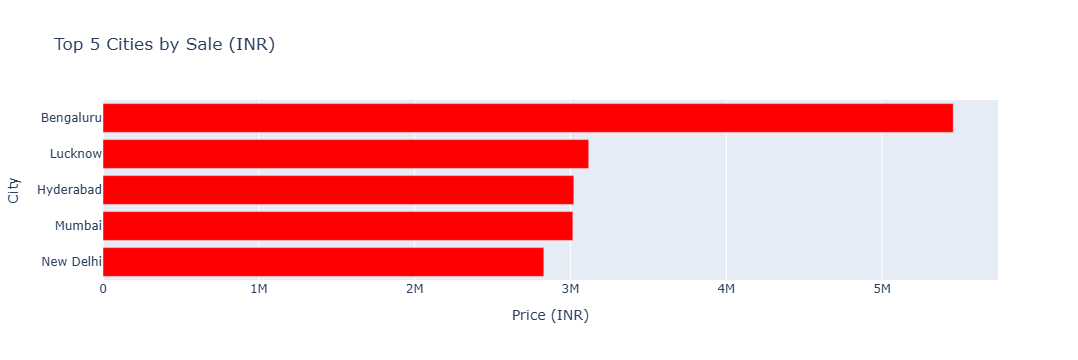

In [62]:
top_5_cities = (
    df.groupby("City")["Price (INR)"]
    .sum()
    .nlargest(5)
   .sort_values()
     .reset_index()
)

fig = px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sale (INR)",
    color_discrete_sequence=["red"]
)

fig.show()